In [2]:
import staircase_to_stimuli as ss
import os

# plot mocs curves for each subject separately

repo_dir = os.getcwd()
data_dir = os.path.join(repo_dir, 'tilt_mocs','data')
#loop thru subjects (only the directories that start with sub there are no letters after sub just numbers, so not sub-eliza but yes sub-21040096)
all_subs = [d for d in os.listdir(data_dir) if d.startswith('sub-') and d[4:].isdigit()]
#get the subs whose IDs are greater than or equal to 21049995
stair_subs = [d for d in all_subs if int(d[4:]) >= 21049995]
#get the subs whose IDs are less than 21049995
fixed_subs = [d for d in all_subs if int(d[4:]) < 21049995]

In [ ]:
#plot stair subs
for sub in stair_subs:
    print(f'Plotting MOCS for subject {sub}...')
    sub_data_dir = os.path.join(data_dir, sub,'ses-0')
    csv_files = [f for f in os.listdir(sub_data_dir) if f.endswith('.csv')] #find the csv filename (it's the only csv in the folder)
    mocs_csv = os.path.join(sub_data_dir, csv_files[0])
    ss.plot_mocs_from_csv(mocs_csv)

plotting fixed MOCS subjects: ['sub-21049992', 'sub-21049993', 'sub-21049994', 'sub-21049991', 'sub-21049990']
Plotting MOCS for subject sub-21049992...


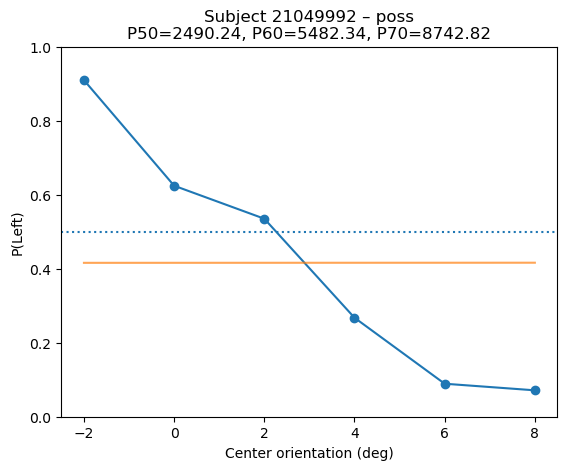

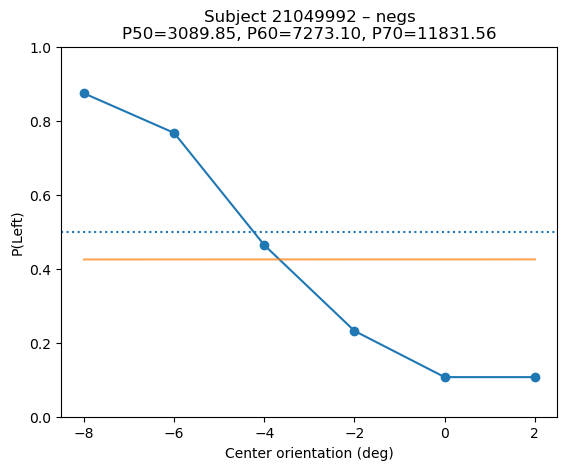

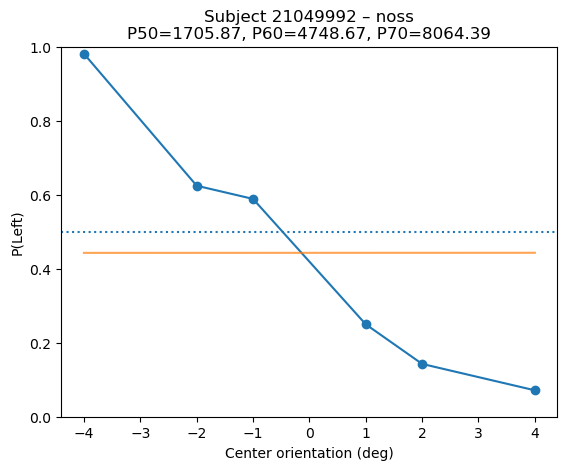

Plotting MOCS for subject sub-21049993...


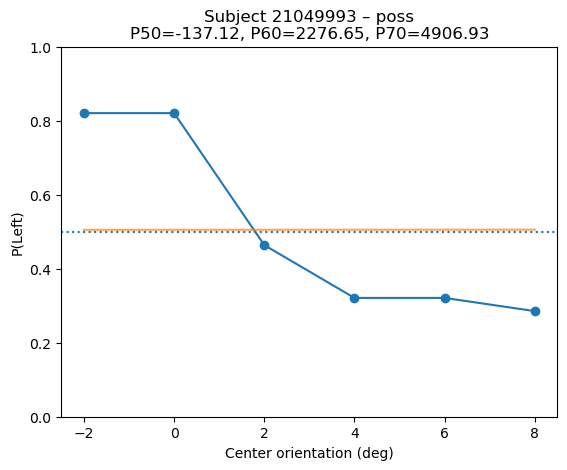

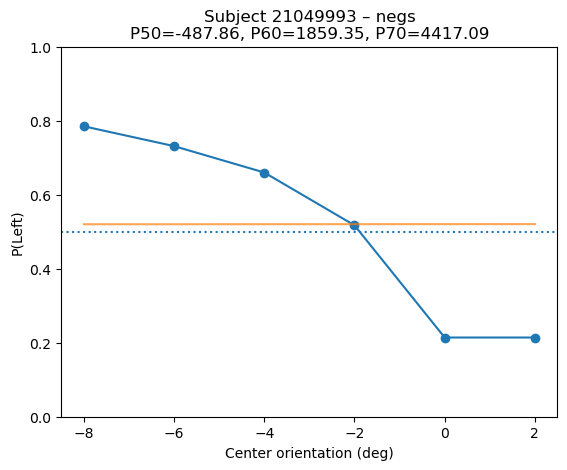

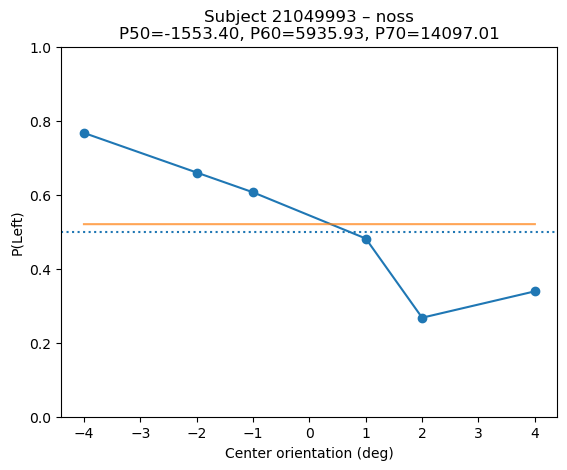

Plotting MOCS for subject sub-21049994...


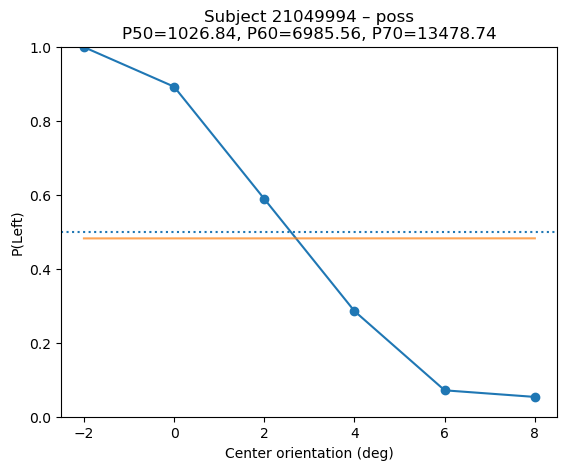

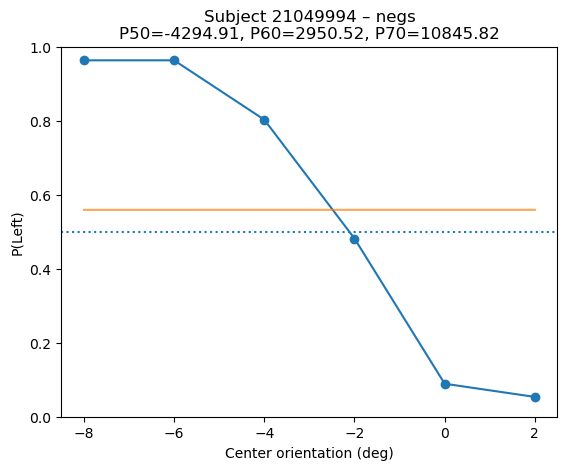

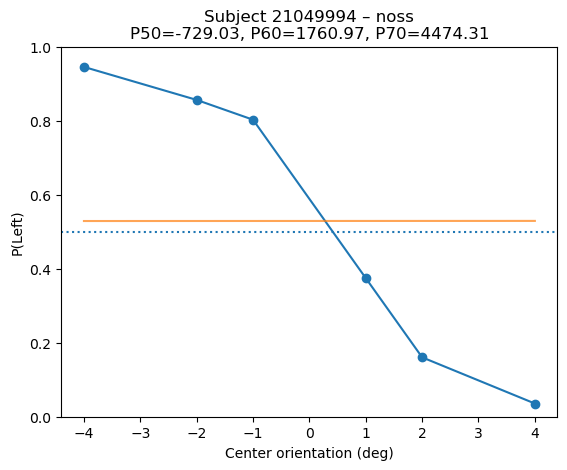

Plotting MOCS for subject sub-21049991...


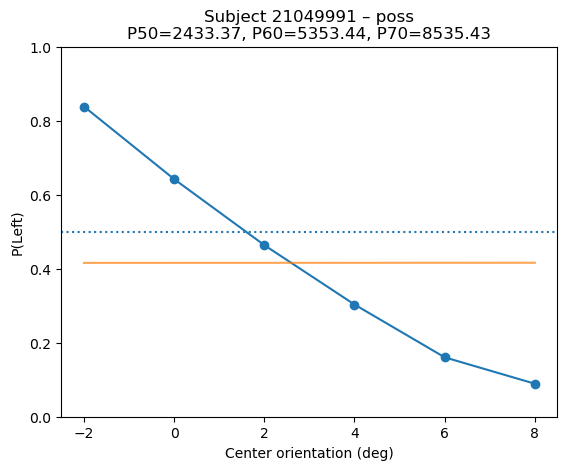

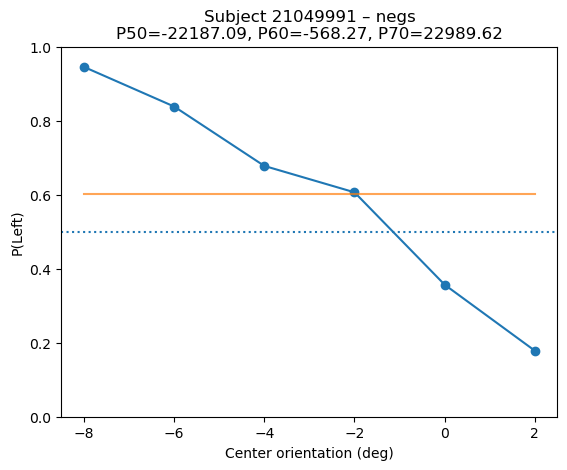

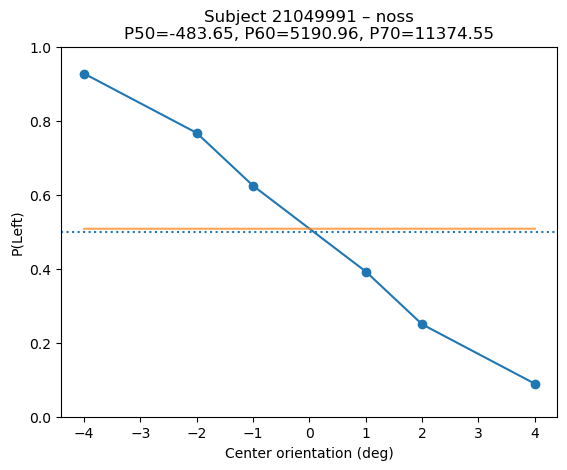

Plotting MOCS for subject sub-21049990...


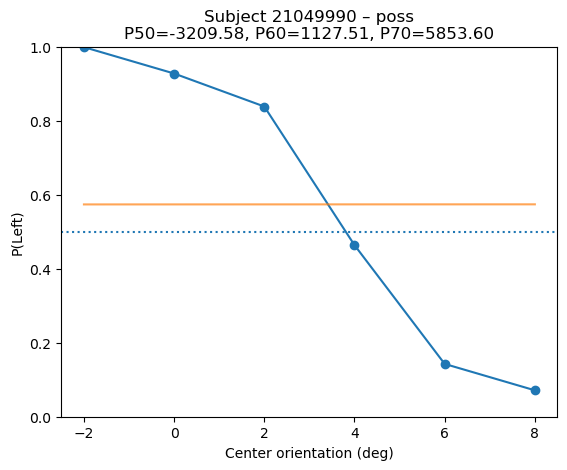

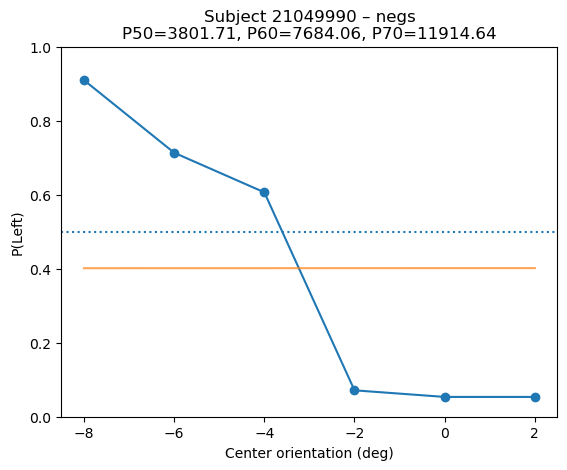

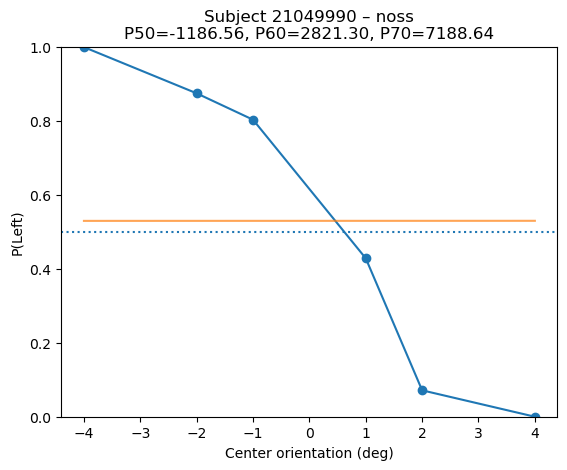

In [5]:
#plot fixed subs
print(f'plotting fixed MOCS subjects: {fixed_subs}')
for sub in fixed_subs:
    print(f'Plotting MOCS for subject {sub}...')
    sub_data_dir = os.path.join(data_dir, sub,'ses-0')
    csv_files = [f for f in os.listdir(sub_data_dir) if f.endswith('.csv')] #find the csv filename (it's the only csv in the folder)
    mocs_csv = os.path.join(sub_data_dir, csv_files[0])
    ss.plot_fixed_mocs_from_csv(mocs_csv)

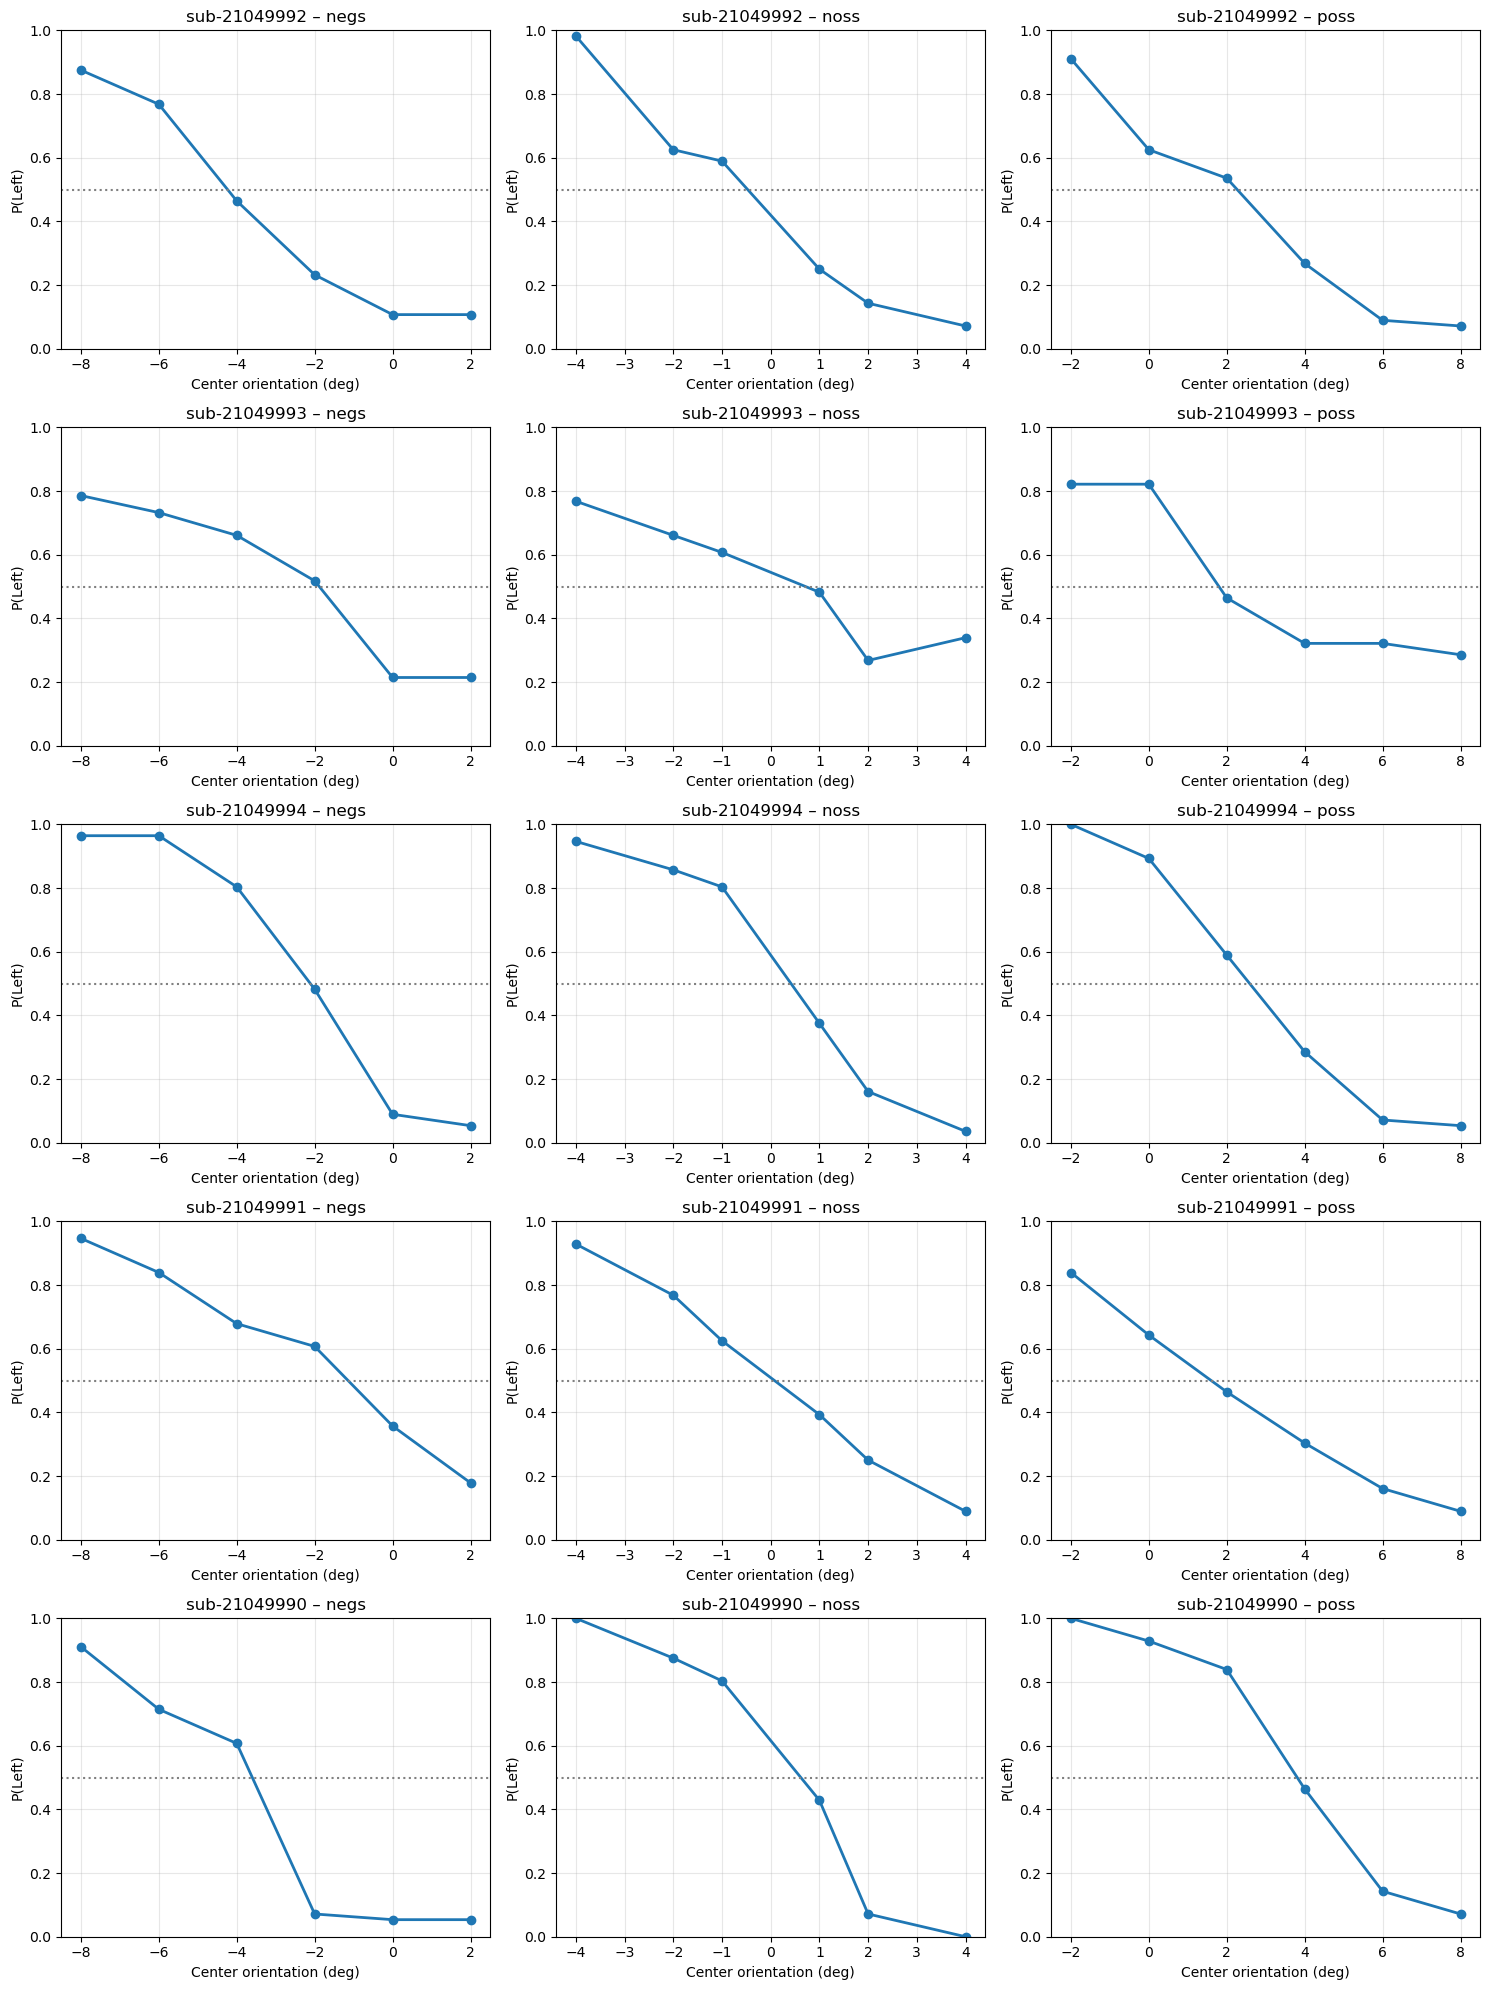

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Collect all subject data
subject_data = {}
for sub in fixed_subs:
    sub_data_dir = os.path.join(data_dir, sub, 'ses-0')
    csv_files = [f for f in os.listdir(sub_data_dir) if f.endswith('.csv')]
    if csv_files:
        mocs_csv = os.path.join(sub_data_dir, csv_files[0])
        df = pd.read_csv(mocs_csv)
        subject_data[sub] = df

# Create mega figure: rows=subjects, columns=[negs, noss, poss]
n_subs = len(subject_data)
fig, axes = plt.subplots(n_subs, 3, figsize=(15, 4*n_subs))

surr_order = ['negs', 'noss', 'poss']  # Left to right column order

for row, (sub, df) in enumerate(subject_data.items()):
    tables = ss.fixed_mocs_psychometric_tables(df)
    
    for col, surr_type in enumerate(surr_order):
        ax = axes[row, col] if n_subs > 1 else axes[col]
        
        if surr_type in tables:
            tab = tables[surr_type]
            x = tab["center"].to_numpy()
            y = tab["p_left"].to_numpy()
            order = np.argsort(x)
            x, y = x[order], y[order]
            
            ax.plot(x, y, "o-", linewidth=2, markersize=6)
            ax.set_ylim(0, 1)
            ax.axhline(0.5, linestyle=":", color='gray')
            ax.set_xlabel("Center orientation (deg)")
            ax.set_ylabel("P(Left)")
            ax.set_title(f"{sub} – {surr_type}")
            ax.grid(True, alpha=0.3)
    
# save plot to /Users/bwinsto2/Downloads/fixed_mocs_mega_figure.png
fig.savefig('/Users/bwinsto2/Downloads/fixed_mocs_mega_figure.png', dpi=300)
plt.tight_layout()
plt.show()